# Perch V2 — Zero-Shot vs Trained Classifier Evaluation

### Data format expected
- **WAV folder**: flat folder of `.wav` files named like `SCW1807_20200711_082500.wav`
- **Annotation JSON**: single JSON file mapping `SCW1807_20200711_082500-contours.json` → list of `{start, end, label}` dicts

### What this notebook does

1. Extracts **fixed 5s windows** and associates the corresponding labels
2. Embeds all windows with **Perch V2**
3. Evaluates **zero-shot** performance using Perch V2's built-in logits
4. Trains a **linear classifier** on top of the embeddings
5. Reports **per-class precision / recall / F1** for both, with plots
6. Performs **Dimensinality Reduction** to asses class separation in 2D and cluster formation.


> **Requirements**: GPU runtime + perch-hoplite installed (cells below)

In order to use Perch V2, you must install this version (or later) of TensorFlow and cuda

In [ ]:
%pip install tensorflow[and-cuda]~=2.20.0rc0

Choose the working gpu

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import tensorflow as tf
import torch

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0], 'GPU')
    # Optional: prevent TF from grabbing all memory
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

2026-04-29 10:43:07.262123: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 10:43:07.316916: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-29 10:43:08.690887: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#@title Imports
import json
import warnings
from pathlib import Path
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report
)
import librosa.display
import soxr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from perch_hoplite.zoo import model_configs

In [4]:
#@title Configuration { vertical-output: true }

#@markdown Folder containing all .wav files
wav_folder = '/data2/mromaniuc/cet-det/datasets/WATKINS/audio'  #@param {type:'string'}

#@markdown Folder for base saving
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/WATKINS'

#@markdown Window size in seconds fed to Perch V2 (default 5.0)
window_size_s = 5.0  #@param {type:'number'}

#@markdown Minimum overlap (s) between an annotation and a window to label it as positive
min_overlap_s = 0.001  #@param {type:'number'}

#@markdown Fraction of data held out for testing
test_size = 0.3  #@param {type:'number'}

#@markdown Random seed
random_seed = 123  #@param {type:'number'}

In [5]:
#@title Load Perch V2 model
model_key = 'perch_v2'
embedding_model = model_configs.load_model_by_name(model_key)
sr = embedding_model.sample_rate

perch_class_names = list(embedding_model.class_list['labels'].classes)
print(f'Model loaded. Sample rate: {sr} Hz')
print(f'Perch V2 built-in classes: {len(perch_class_names)}')

I0000 00:00:1777452453.074946 3356221 gpu_device.cc:2020] Created device /device:GPU:0 with 20750 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9
I0000 00:00:1777452453.472721 3356221 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20750 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


Model loaded. Sample rate: 32000 Hz
Perch V2 built-in classes: 14795


Found 9 species folders


100%|██████████| 9/9 [00:00<00:00, 311.72it/s]



=== Global Summary (451 files) ===
Min:    0.221s
Max:    1220.101s
Mean:   17.865s
Median: 1.677s

=== Proportion by length (global) ===
  <  1.00s :  104 (23.1%)
  <  2.00s :  259 (57.4%)
  <  3.00s :  316 (70.1%)
  <  3.75s :  334 (74.1%)
  <  5.00s :  346 (76.7%)
  < 10.00s :  367 (81.4%)
  >= 5.00s :  105 (23.3%)

=== Per-species summary ===
                            count   mean  median   min      max
species                                                        
Balaenoptera_acutorostrata     17   1.18    1.34  0.71     1.42
Balaenoptera_physalus          50  49.54   43.85  5.94   101.91
Delphinus_delphis              52   6.61    1.85  0.22    53.05
Globicephala_melas             65   8.05    1.42  0.28    69.98
Grampus_griseus                67   2.57    0.61  0.25    35.63
Orcinus_orca                   35   3.01    2.09  1.05    14.25
Physeter_macrocephalus         60  70.71    3.88  0.40  1220.10
Stenella_coeruleoalba          81   1.77    1.35  0.26    24.92
Tursiops_t

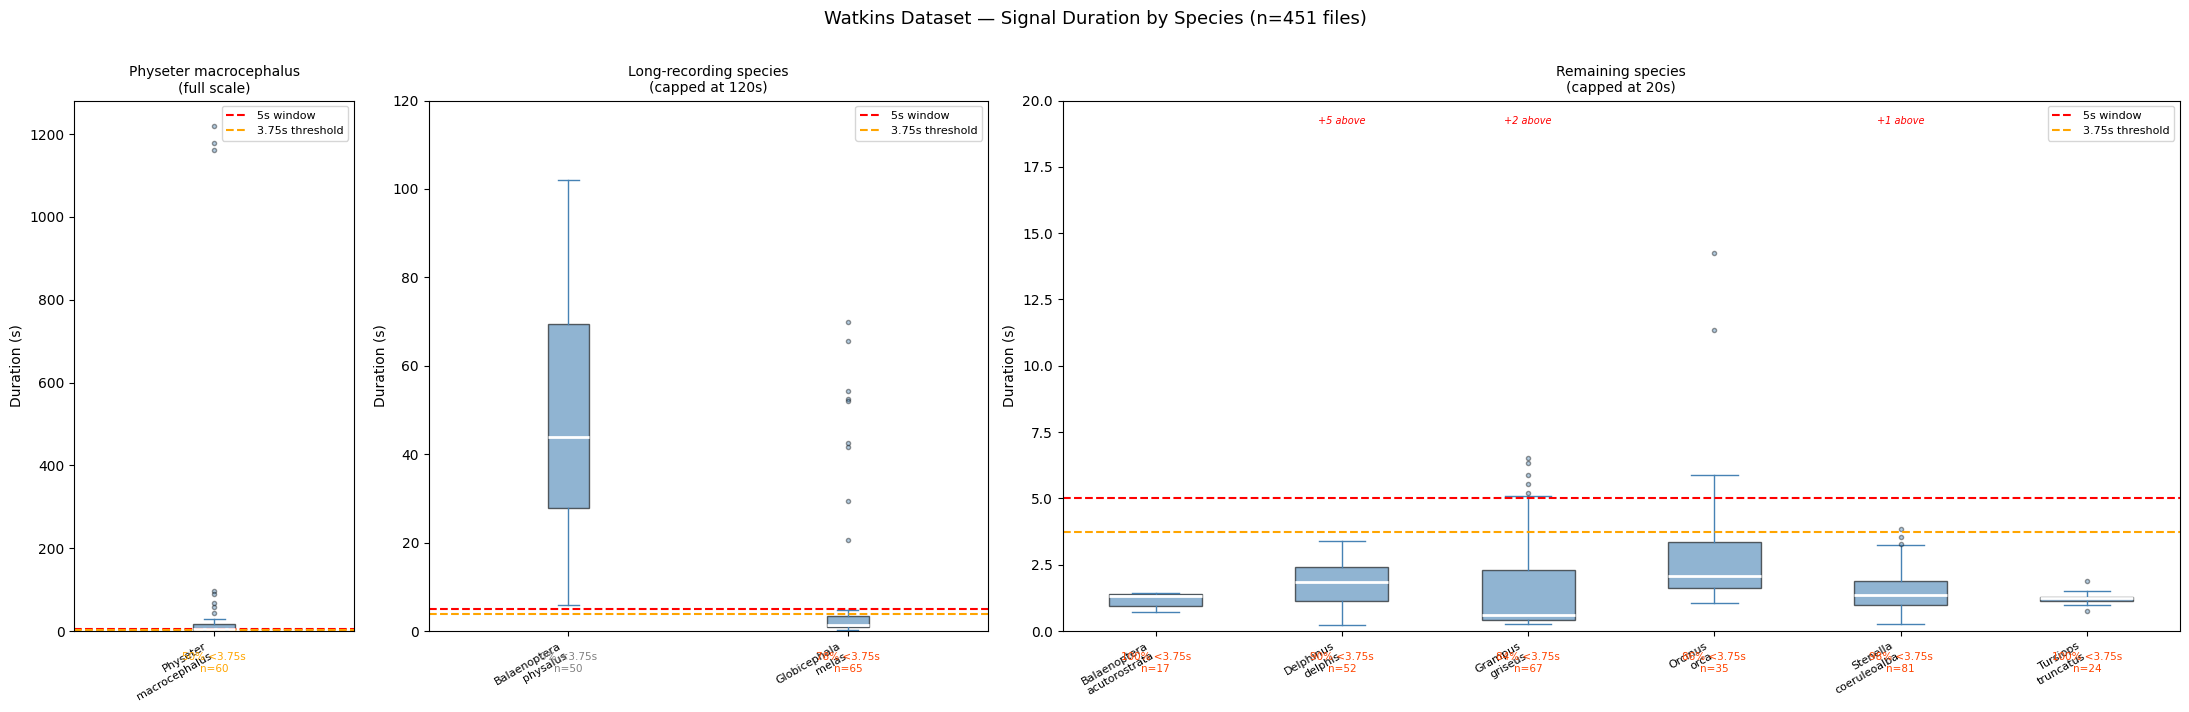

Saved: watkins_duration_boxplots.png


In [ ]:
#@title Watkins Dataset — Duration Distribution Explorer
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from pathlib import Path
from tqdm import tqdm

wav_folder = Path(wav_folder)
species_dirs = sorted([d for d in wav_folder.iterdir() if d.is_dir()])
print(f'Found {len(species_dirs)} species folders')

# ── Collect durations per species ────────────────────────────────────────────
records = []
skipped = []

for species_dir in tqdm(species_dirs):
    species = species_dir.name
    wav_files = sorted(list(species_dir.glob('*.wav')) + list(species_dir.glob('*.WAV')))
    for wf in wav_files:
        try:
            info = sf.info(str(wf))  # fast — no decoding
            duration = info.duration
            records.append({'species': species, 'duration_s': duration, 'file': wf.name})
        except Exception as e:
            skipped.append((wf.name, str(e)))

import pandas as pd
df = pd.DataFrame(records)

# ── Global summary ────────────────────────────────────────────────────────────
print(f"\n=== Global Summary ({len(df)} files) ===")
print(f"Min:    {df.duration_s.min():.3f}s")
print(f"Max:    {df.duration_s.max():.3f}s")
print(f"Mean:   {df.duration_s.mean():.3f}s")
print(f"Median: {df.duration_s.median():.3f}s")

print(f"\n=== Proportion by length (global) ===")
for t in [1, 2, 3, 3.75, 5, 10]:
    n = (df.duration_s < t).sum()
    print(f"  < {t:5.2f}s : {n:4d} ({100*n/len(df):.1f}%)")
n = (df.duration_s >= 5).sum()
print(f"  >= 5.00s : {n:4d} ({100*n/len(df):.1f}%)")

print(f"\n=== Per-species summary ===")
per_species = df.groupby('species')['duration_s'].agg(['count','mean','median','min','max'])
print(per_species.round(2).to_string())



# ── Violin plot per species ───────────────────────────────────────────────────
species_list = sorted(df['species'].unique())
n_species = len(species_list)
#@title Duration Boxplots — 3 panels by distribution group
fig, axes = plt.subplots(1, 3, figsize=(22, 7),
                         gridspec_kw={'width_ratios': [1, 2, 4]})

group_long   = ['Physeter_macrocephalus', 'Balaenoptera_physalus', 'Globicephala_melas']
group_rest   = [s for s in species_list if s not in group_long]

def plot_boxes(ax, species_subset, title, y_max=None):
    data   = [df[df['species'] == s]['duration_s'].values for s in species_subset]
    labels = [s.replace('_', '\n') for s in species_subset]

    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2),
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    whiskerprops=dict(color='steelblue'),
                    capprops=dict(color='steelblue'),
                    flierprops=dict(marker='o', markersize=3,
                                    markerfacecolor='steelblue', alpha=0.4,
                                    linestyle='none'))

    ax.axhline(y=5,    color='red',    linestyle='--', linewidth=1.5, label='5s window')
    ax.axhline(y=3.75, color='orange', linestyle='--', linewidth=1.5, label='3.75s threshold')

    # annotate % below 3.75s + n files
    for i, (s, vals) in enumerate(zip(species_subset, data)):
        pct_below = 100 * np.mean(vals < 3.75)
        color = 'orangered' if pct_below > 70 else 'orange' if pct_below > 30 else 'gray'
        ax.text(i + 1, -0.04, f'{pct_below:.0f}% <3.75s\nn={len(vals)}',
                ha='center', va='top', fontsize=7.5, color=color,
                transform=ax.get_xaxis_transform())

    # annotate clipped outliers if y_max set
    if y_max:
        for i, (s, vals) in enumerate(zip(species_subset, data)):
            n_clipped = (vals > y_max).sum()
            if n_clipped > 0:
                ax.text(i + 1, y_max * 0.97, f'+{n_clipped} above',
                        ha='center', va='top', fontsize=7, color='red', style='italic')

    ax.set_xticks(range(1, len(species_subset) + 1))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Duration (s)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(bottom=0, top=y_max)

# Panel 1: Physeter only — full scale
plot_boxes(axes[0], ['Physeter_macrocephalus'],
           'Physeter macrocephalus\n(full scale)')

# Panel 2: Balaenoptera physalus + Globicephala melas — capped at 120s
plot_boxes(axes[1], ['Balaenoptera_physalus', 'Globicephala_melas'],
           'Long-recording species\n(capped at 120s)',
           y_max=120)

# Panel 3: all remaining species — capped at 20s
plot_boxes(axes[2], group_rest,
           'Remaining species\n(capped at 20s)',
           y_max=20)

plt.suptitle('Watkins Dataset — Signal Duration by Species (n=451 files)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/watkins_duration_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: watkins_duration_boxplots.png")

If we were to keep only the samples above 3.75 seconds, we would loose all data for for species apart from 3, so we smaple the floor signal and add it at the rest of the audio, placing the signal at random starting points inside the 5 second window

In [7]:
#@title Build windows, QC spectrograms, save windows to disk
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import soxr
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import random
import pickle

TARGET_SR        = 32000
TARGET_SAMPLES   = int(5.0 * TARGET_SR)  # 160000
MIN_TAIL_SEC     = 1.0
WINDOWS_SAVE_PATH = 'windows_df.pkl'

np.random.seed(42)
random.seed(42)

In [ ]:
# ── Slow amplitude drift ──────────────────────────────────────────────────────
def apply_slow_drift(signal, strength=0.15):
    n      = len(signal)
    n_ctrl = max(10, n // (TARGET_SR // 2))
    ctrl   = np.random.uniform(1.0 - strength, 1.0 + strength, n_ctrl)
    return (signal * np.interp(
        np.linspace(0, 1, n),
        np.linspace(0, 1, n_ctrl),
        ctrl
    )).astype(np.float32)

# ── Mel-space noise estimation ────────────────────────────────────────────────
def estimate_noise_mel(audio_raw, sr, n_mels=128, noise_floor_percentile=20):
    S            = librosa.feature.melspectrogram(
        y=audio_raw, sr=sr, n_mels=n_mels,
        hop_length=160, n_fft=1024, power=2.0
    )
    frame_energy = S.mean(axis=0)
    threshold    = np.percentile(frame_energy, noise_floor_percentile)
    quiet_idx    = frame_energy <= threshold
    if np.sum(quiet_idx) < 5:
        quiet_idx[:] = True
    mel_profile  = np.mean(S[:, quiet_idx], axis=1)
    rms_noise    = np.sqrt(np.mean(
        audio_raw[:int(np.sum(quiet_idx) * 160)] ** 2
    ))
    return mel_profile, rms_noise

# ── Mel-matched noise synthesis ───────────────────────────────────────────────
def generate_mel_matched_noise(mel_profile, rms_noise, length, sr):
    variation     = np.random.normal(0, 0.05, size=mel_profile.shape)
    local_profile = np.abs(mel_profile * (1.0 + variation))
    noise         = np.random.randn(length).astype(np.float32)
    S             = librosa.feature.melspectrogram(
        y=noise, sr=sr, n_mels=len(local_profile),
        hop_length=160, n_fft=1024, power=2.0
    )
    S_mean        = np.mean(S, axis=1) + 1e-8
    S_scaled      = S * (local_profile[:, None] / S_mean[:, None])
    noise_matched = librosa.feature.inverse.mel_to_audio(
        S_scaled, sr=sr, hop_length=160, n_fft=1024
    )[:length]
    current_rms   = np.sqrt(np.mean(noise_matched ** 2))
    if current_rms > 0:
        noise_matched *= (rms_noise / current_rms)
    return apply_slow_drift(noise_matched.astype(np.float32))

# ── Extend short signal ───────────────────────────────────────────────────────
def extend_to_length(audio_raw, target_len,
                     noise_floor_percentile=20, fade_samples=320):
    n = len(audio_raw)
    if n >= target_len:
        chunk = audio_raw[:target_len]
        peak  = np.max(np.abs(chunk))
        if peak > 0:
            chunk = chunk / peak * 0.95
        return chunk.astype(np.float32), 0

    mel_profile, rms_noise = estimate_noise_mel(
        audio_raw, TARGET_SR,
        noise_floor_percentile=noise_floor_percentile
    )
    background = generate_mel_matched_noise(
        mel_profile, rms_noise, target_len, TARGET_SR
    )
    max_start  = target_len - n
    start      = np.random.randint(0, max_start + 1)
    fade       = min(fade_samples, n // 4,
                     max(start, 1), max(target_len - (start + n), 1))
    sig        = audio_raw.copy()

    if fade > 1:
        t                              = np.linspace(0.0, 1.0, fade, dtype=np.float32)
        background[start:start+fade]  *= (1.0 - t)
        sig[:fade]                    *= t
        sig[-fade:]                   *= (1.0 - t)
        background[start+n-fade:start+n] *= t

    output          = background.copy()
    output[start:start + n] += sig
    peak            = np.max(np.abs(output))
    if peak > 0:
        output = output / peak * 0.95
    return output.astype(np.float32), start

# ── Windowing ─────────────────────────────────────────────────────────────────
def file_to_windows(audio_raw, target_len, min_tail_samples):
    n      = len(audio_raw)
    if n < target_len:
        window, start = extend_to_length(audio_raw, target_len)
        return [(window, start, n)], ['extended']

    windows, kinds = [], []
    n_full = n // target_len
    for i in range(n_full):
        chunk = audio_raw[i * target_len:(i + 1) * target_len].copy()
        peak  = np.max(np.abs(chunk))
        if peak > 0:
            chunk = chunk / peak * 0.95
        windows.append((chunk.astype(np.float32), 0, target_len))
        kinds.append('real')

    tail = audio_raw[n_full * target_len:]
    if len(tail) >= min_tail_samples:
        window, start = extend_to_length(tail, target_len)
        windows.append((window, start, len(tail)))
        kinds.append('tail_extended')

    return windows, kinds

# ── Build windows_df ──────────────────────────────────────────────────────────
species_dirs     = sorted([d for d in Path(wav_folder).iterdir() if d.is_dir()])
min_tail_samples = int(MIN_TAIL_SEC * TARGET_SR)
windows_list     = []
skipped_files    = []

print('Building windows...')
for species_dir in tqdm(species_dirs, desc='Species'):
    species   = species_dir.name
    wav_files = sorted(
        list(species_dir.glob('*.wav')) + list(species_dir.glob('*.WAV'))
    )
    for wf in tqdm(wav_files, desc=species, leave=False):
        try:
            audio_raw, file_sr = sf.read(str(wf), always_2d=False)
            if audio_raw.ndim > 1:
                audio_raw = audio_raw.mean(axis=1)
            audio_raw = audio_raw.astype(np.float32)
            if file_sr != TARGET_SR:
                audio_raw = soxr.resample(audio_raw, file_sr, TARGET_SR)

            original_duration   = len(audio_raw) / TARGET_SR
            file_windows, kinds = file_to_windows(
                audio_raw, TARGET_SAMPLES, min_tail_samples
            )
            for win_idx, (window_audio, sig_start, sig_len) in enumerate(file_windows):
                windows_list.append({
                    'species':             species,
                    'label':               species,
                    'source_file':         wf.name,
                    'window_idx':          win_idx,
                    'window_kind':         kinds[win_idx],
                    'original_duration_s': original_duration,
                    'native_sr':           file_sr,
                    'sig_start_sample':    sig_start,
                    'sig_len_sample':      sig_len,
                    'audio':               window_audio,
                })
        except Exception as e:
            skipped_files.append((str(wf), str(e)))
            print(f'  SKIPPED {wf.name}: {e}')

windows_df = pd.DataFrame(windows_list)

print(f'\nTotal 5s windows : {len(windows_df)}')
print(f'Species          : {windows_df["species"].nunique()}')
if skipped_files:
    print(f'Skipped files    : {len(skipped_files)}')
print('\n=== Windows per species ===')
print(windows_df['species'].value_counts().to_string())
print('\n=== Window kind breakdown ===')
print(windows_df.groupby(['species','window_kind']).size()
      .unstack(fill_value=0).to_string())

# ── Save to disk ──────────────────────────────────────────────────────────────
windows_df.to_pickle(WINDOWS_SAVE_PATH)
print(f'\nSaved windows_df → {WINDOWS_SAVE_PATH}')

# ── QC spectrograms ───────────────────────────────────────────────────────────
n_species = len(species_dirs)
fig, axes = plt.subplots(n_species, 3, figsize=(18, n_species * 3.2))

for row, species_dir in enumerate(species_dirs):
    species   = species_dir.name
    sub       = windows_df[windows_df['species'] == species]
    # sample 3 rows from the dataframe — audio already built, no recomputation
    samples   = sub.sample(min(3, len(sub)), random_state=42).to_dict('records')
    samples  += [None] * (3 - len(samples))

    for col, rec in enumerate(samples):
        ax = axes[row][col]
        if rec is None:
            ax.axis('off')
            continue
        try:
            window_audio = rec['audio']
            kind         = rec['window_kind']
            sig_start    = rec['sig_start_sample']
            sig_len      = rec['sig_len_sample']
            orig_dur     = rec['original_duration_s']

            S    = librosa.feature.melspectrogram(
                y=window_audio, sr=TARGET_SR,
                n_mels=128, fmin=0, fmax=TARGET_SR // 2,
                hop_length=160, n_fft=1024
            )
            S_db = librosa.power_to_db(S, ref=np.max)
            librosa.display.specshow(
                S_db, sr=TARGET_SR, hop_length=160,
                fmin=0, fmax=TARGET_SR // 2,
                x_axis='time', y_axis='mel',
                ax=ax, cmap='magma'
            )

            if kind in ('extended', 'tail_extended'):
                ax.axvline(sig_start / TARGET_SR, color='cyan',
                           linewidth=1.5, linestyle='--',
                           label=f'start {sig_start/TARGET_SR:.2f}s')
                ax.axvline((sig_start + sig_len) / TARGET_SR, color='lime',
                           linewidth=1.5, linestyle='--',
                           label=f'end {(sig_start+sig_len)/TARGET_SR:.2f}s')
                ax.legend(fontsize=5, loc='upper right')

            title_color = ('orangered' if kind == 'extended' else
                           'gold'      if kind == 'tail_extended' else 'white')
            ax.set_title(
                f'{rec["source_file"][:28]}\n{orig_dur:.2f}s [{kind}]',
                fontsize=7, color=title_color
            )
            ax.set_xlabel('Time (s)', fontsize=6)
            ax.set_ylabel('Hz',       fontsize=6)
            ax.tick_params(labelsize=6)

        except Exception as e:
            ax.set_title(f'ERROR\n{str(e)[:40]}', fontsize=7)
            ax.axis('off')

    axes[row][0].set_ylabel(
        species.replace('_', '\n'), fontsize=8,
        fontweight='bold', rotation=0, labelpad=80, va='center'
    )

plt.suptitle(
    f'Watkins — 5s windows QC | TARGET_SR={TARGET_SR}Hz | '
    f'mel-matched noise, random placement, slow drift\n'
    'cyan = signal start | lime = signal end | '
    'orange = extended | gold = tail_extended | white = real',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.savefig('figures/watkins_spectrogram_qc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/watkins_spectrogram_qc.png')

Building windows...


Species:   0%|          | 0/9 [00:00<?, ?it/s]

Species:  33%|███▎      | 3/9 [05:26<12:03, 120.60s/it]

In [8]:
#@title Load windows + extract embeddings
import pickle
import numpy as np
from tqdm import tqdm

# load pre-built windows — no recomputation
windows_df = pd.read_pickle('windows_df.pkl')
print(f'Loaded {len(windows_df)} windows')

embeddings_list, logits_list, labels_list, failed_files = [], [], [], []

for i, row in tqdm(windows_df.iterrows(), total=len(windows_df)):
    try:
        audio = row['audio'].astype(np.float32)
        if len(audio) != TARGET_SAMPLES:
            audio = np.pad(audio, (0, TARGET_SAMPLES - len(audio))) \
                    if len(audio) < TARGET_SAMPLES else audio[:TARGET_SAMPLES]

        out = embedding_model.embed(audio)
        embeddings_list.append(out.embeddings[0].mean(axis=0))
        logits_list.append(out.logits['label'][0])
        labels_list.append(row['label'])

    except Exception as e:
        failed_files.append(f"{row['species']}/{row['source_file']}")
        print(f'  FAILED [{i}] — {repr(e)}')

    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(windows_df)} embedded...')

X = np.stack(embeddings_list)
Z = np.stack(logits_list)
y = np.array(labels_list)

print(f'\nDone. {len(X)} embedded, {len(failed_files)} failed.')
print(f'Embedding shape : {X.shape}')
print(f'Logits shape    : {Z.shape}')

Loaded 1877 windows


  0%|          | 0/1877 [00:00<?, ?it/s]2026-04-29 10:50:27.273863: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fcb9c06dca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-29 10:50:27.273896: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-04-29 10:50:27.602821: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-29 10:50:27.650679: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92100
2026-04-29 10:50:28.538737: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_55', 68 bytes spill stores, 68 bytes spill loads

2026-04-29 10:50:28.811327: I external/local_xla/xla/stream_executor/cuda/subprocess_co

  100/1877 embedded...


 11%|█         | 209/1877 [00:16<00:32, 51.32it/s]

  200/1877 embedded...


...

  1700/1877 embedded...


 96%|█████████▋| 1810/1877 [00:46<00:01, 52.68it/s]

  1800/1877 embedded...


100%|██████████| 1877/1877 [00:48<00:00, 39.06it/s]



Done. 1877 embedded, 0 failed.
Embedding shape : (1877, 1536)
Logits shape    : (1877, 14795)


In [10]:
# ── Build metadata (align with succeeded rows) ────────────────────────────────
failed_idx_set  = set([f[0] for f in failed_files])
succeeded_mask  = [i for i in windows_df.index if i not in failed_idx_set]
metadata_df     = windows_df.loc[succeeded_mask].copy().reset_index(drop=True)
metadata_df     = metadata_df.drop(columns=['audio'])  # don't save audio in csv
metadata_df['embedding_idx'] = metadata_df.index

# ── NaN diagnostic ────────────────────────────────────────────────────────────
nan_in_X = np.isnan(X).any(axis=1)
nan_in_Z = np.isnan(Z).any(axis=1)
nan_any  = nan_in_X | nan_in_Z

print('\n=== NaN DIAGNOSTIC ===')
print(f'Total windows          : {len(X)}')
print(f'Rows with NaN in X     : {nan_in_X.sum()}')
print(f'Rows with NaN in Z     : {nan_in_Z.sum()}')
print(f'Rows with NaN in either: {nan_any.sum()}')

if nan_any.sum() > 0:
    for idx in np.where(nan_any)[0]:
        row  = metadata_df.iloc[idx]
        print(f'  row {idx:5d} | {row["species"]:30s} | '
              f'{row["source_file"]} | '
              f'NaN in X: {np.isnan(X[idx]).sum()}, '
              f'NaN in Z: {np.isnan(Z[idx]).sum()}')

    pct = nan_any.sum() / len(X) * 100
    if pct < 5.0:
        print(f'\n{nan_any.sum()} NaN rows ({pct:.2f}%) — safe to drop.')
        valid        = ~nan_any
        X_save       = X[valid]
        Z_save       = Z[valid]
        y_save       = y[valid]
        metadata_save = metadata_df[valid].reset_index(drop=True)
        metadata_save['embedding_idx'] = metadata_save.index
    else:
        print(f'\nWARNING: {pct:.2f}% NaN — too many to drop, saving with NaNs.')
        X_save, Z_save, y_save, metadata_save = X, Z, y, metadata_df
else:
    print('\nNo NaN values — data is clean.')
    X_save, Z_save, y_save, metadata_save = X, Z, y, metadata_df

# ── Save ──────────────────────────────────────────────────────────────────────
os.makedirs(f'{save_dir}/embeddings', exist_ok=True)

np.save(f'{save_dir}/embeddings/X_embeddings.npy', X_save)
np.save(f'{save_dir}/embeddings/Z_logits.npy',     Z_save)
np.save(f'{save_dir}/embeddings/y_labels.npy',     y_save)
metadata_save.to_csv(f'{save_dir}/embeddings/metadata.csv', index=False)

print(f'\n=== SAVED TO {save_dir}/embeddings/ ===')
print(f'  X_embeddings.npy : {X_save.shape}')
print(f'  Z_logits.npy     : {Z_save.shape}')
print(f'  y_labels.npy     : {y_save.shape}')
print(f'  metadata.csv     : {len(metadata_save)} rows')
print(f'\nClass distribution:')
print(pd.Series(y_save).value_counts())



=== NaN DIAGNOSTIC ===
Total windows          : 1877
Rows with NaN in X     : 0
Rows with NaN in Z     : 0
Rows with NaN in either: 0

No NaN values — data is clean.

=== SAVED TO /data2/mromaniuc/cet-det/models/perch_v2/WATKINS/embeddings/ ===
  X_embeddings.npy : (1877, 1536)
  Z_logits.npy     : (1877, 14795)
  y_labels.npy     : (1877,)
  metadata.csv     : 1877 rows

Class distribution:
Physeter_macrocephalus        875
Balaenoptera_physalus         510
Globicephala_melas            144
Delphinus_delphis             102
Stenella_coeruleoalba          85
Grampus_griseus                81
Orcinus_orca                   39
Tursiops_truncatus             24
Balaenoptera_acutorostrata     17
Name: count, dtype: int64


# retrieving the data and performing zero-shot and fully-supervised classifications

In [11]:
X_clean =  np.load(f'{save_dir}/embeddings/X_embeddings.npy')  
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')   
Z_clean = np.load(f'{save_dir}/embeddings/Z_logits.npy')   

metadata_clean = pd.read_csv(f'{save_dir}/embeddings/metadata.csv')

print(f'Clean shapes — X: {X_clean.shape}, Z: {Z_clean.shape}, y: {y_clean.shape}')
print(f'Class distribution:')
print(pd.Series(y_clean).value_counts())

Clean shapes — X: (1877, 1536), Z: (1877, 14795), y: (1877,)
Class distribution:
Physeter_macrocephalus        875
Balaenoptera_physalus         510
Globicephala_melas            144
Delphinus_delphis             102
Stenella_coeruleoalba          85
Grampus_griseus                81
Orcinus_orca                   39
Tursiops_truncatus             24
Balaenoptera_acutorostrata     17
Name: count, dtype: int64


In [26]:
# Search for dolphin/whale/cetacean related classes
for name in perch_class_names:
    if any(term in name.lower() for term in ['dolphin', 'orca', 'whale', 'balaena', 'balaenoptera', 'Stenella_coeruleoalba', 'Grampus_griseus', 'Physeter_macrocephalus', 'Globicephala_melas', 'Balaenoptera_physalus', 'tursiops', 'whale', 'cetac', 'porpoise', 'whistle', 'cetacean', 'delphinus', 'delphis', 'cetacea']):
        print(name)

Balaena mysticetus
Balaenoptera physalus
Budorcas taxicolor
Didelphis virginiana
Eubalaena australis
Eubalaena glacialis
Ingerophrynus biporcatus
Ingerophrynus quadriporcatus
Myzomela adolphinae
Orcinus orca
Phylloscopus whistleri
Sternula balaenarum
Tursiops truncatus


In [12]:
#@title Zero-shot species analysis — what does Perch think your sounds are? (Watkins)

class_names_list = list(embedding_model.class_list['labels'].classes)

# Expected Perch class for each Watkins species folder.
# Some mappings use Perch's closest available family member when the exact
# species isn't in Perch's vocabulary.
expected_mapping = {
    'Physeter_macrocephalus':    'Balaenoptera physalus',   # verify — is this intended?
    'Balaenoptera_physalus':     'Balaenoptera physalus',
    'Globicephala_melas':        'Balaenoptera physalus',   # verify — is this intended?
    'Delphinus_delphis':         'Tursiops truncatus',
    'Stenella_coeruleoalba':     'Tursiops truncatus',
    'Grampus_griseus':           'Tursiops truncatus',
    'Orcinus_orca':              'Orcinus orca',
    'Tursiops_truncatus':        'Tursiops truncatus',
    'Balaenoptera_acutorostrata':'Balaenoptera physalus',
}

# Build masks from the species column in the cleaned data
masks = {species: (y_clean == species) for species in expected_mapping}

# Mean logits per species
mean_logits = {species: Z_clean[mask].mean(axis=0)
               for species, mask in masks.items() if mask.sum() > 0}

# Print top 20 Perch classes per Watkins species
for species, logits in mean_logits.items():
    top_idx = np.argsort(logits)[::-1][:20]
    expected = expected_mapping[species]
    expected_idx = class_names_list.index(expected)
    expected_rank = np.where(np.argsort(logits)[::-1] == expected_idx)[0][0] + 1
    print(f'TOP 20 PERCH CLASSES FOR {species.upper()} (n={masks[species].sum()}):')
    print(f'  Expected: "{expected}" — rank #{expected_rank}, logit={logits[expected_idx]:.3f}')
    print('-' * 60)
    for idx in top_idx:
        marker = '  <-- expected' if idx == expected_idx else ''
        print(f'  {logits[idx]:6.3f}  {class_names_list[idx]}{marker}')
    print()

# --- Candidate comparison tables ---

def safe_idx(name):
    try:
        return class_names_list.index(name)
    except ValueError:
        print(f'  WARNING: "{name}" not in Perch class list, skipping')
        return None

dolphin_candidate_names = [
    'Tursiops truncatus',
    'Orcinus orca'
]
baleen_candidate_names = [
    'Balaenoptera physalus',
    'Physeter macrocephalus',
]

def print_candidate_table(title, candidate_names):
    candidates = {n: safe_idx(n) for n in candidate_names}
    candidates = {n: i for n, i in candidates.items() if i is not None}
    if not candidates:
        return

    print(title)
    print('-' * (35 + 20 * len(mean_logits)))
    header = f'  {"Perch class":35s}'
    for species in mean_logits:
        header += f'  {species[:18]:>18s}'
    print(header)
    print('-' * (35 + 20 * len(mean_logits)))
    for name, idx in candidates.items():
        row = f'  {name:35s}'
        for species, logits in mean_logits.items():
            rank = np.where(np.argsort(logits)[::-1] == idx)[0][0] + 1
            row += f'  {logits[idx]:6.3f} (#{rank:<4d})'
        print(row)
    print()

print_candidate_table('DOLPHIN / TOOTHED WHALE CANDIDATES:', dolphin_candidate_names)
print_candidate_table('BALEEN WHALE CANDIDATES:', baleen_candidate_names)


TOP 20 PERCH CLASSES FOR PHYSETER_MACROCEPHALUS (n=875):
  Expected: "Balaenoptera physalus" — rank #13732, logit=-5.203
------------------------------------------------------------
   5.327  Water
   5.294  Strix aluco
   4.802  Corvus corax
   4.777  Domestic_sounds_and_home_sounds
   4.765  Bubo virginianus
   4.588  Bubo bubo
   4.563  Liquid
   4.509  Asio otus
   4.460  Rain
   4.365  Fringilla coelebs
   4.353  Strix varia
   4.332  Turdus merula
   4.227  Phylloscopus collybita
   4.225  Parus major
   4.195  Corvus brachyrhynchos
   4.187  Erithacus rubecula
   4.171  Caprimulgus europaeus
   4.167  Coturnicops noveboracensis
   4.141  Emberiza calandra
   4.092  Cyanistes caeruleus

TOP 20 PERCH CLASSES FOR BALAENOPTERA_PHYSALUS (n=510):
  Expected: "Balaenoptera physalus" — rank #13470, logit=-5.050
------------------------------------------------------------
   8.170  Music
   8.166  Musical_instrument
   6.943  Keyboard_(musical)
   6.594  Percussion
   5.865  Bowed_string

In [14]:
from sklearn.model_selection import StratifiedGroupKFold

le = LabelEncoder()
y_enc = le.fit_transform(y_clean)
class_names = list(le.classes_)
print('Classes:', class_names)

# Reconstruct the aligned windows_df — drop rows that failed to embed,
# matching how X_clean / Z_clean / y_clean were built
windows_df_clean = windows_df

# Sanity check: must match X_clean length
assert len(windows_df_clean) == len(X_clean), \
    f'mismatch: {len(windows_df_clean)} windows vs {len(X_clean)} embeddings'

groups = windows_df_clean['source_file'].to_numpy()

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_seed)
train_idx, test_idx = next(sgkf.split(X_clean, y_enc, groups=groups))

X_train, X_test = X_clean[train_idx], X_clean[test_idx]
y_train, y_test = y_enc[train_idx], y_enc[test_idx]
Z_train, Z_test = Z_clean[train_idx], Z_clean[test_idx]

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print(f'Test fraction: {len(X_test) / len(X_clean):.2%}')

# Verify no file leakage
train_files = set(groups[train_idx])
test_files = set(groups[test_idx])
print(f'Files in train only: {len(train_files - test_files)}')
print(f'Files in test only:  {len(test_files - train_files)}')

print('\nTest set class distribution:')
test_counts = pd.Series(le.inverse_transform(y_test)).value_counts()
print(test_counts.to_string())

Classes: ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus']
Train: 1446  |  Test: 431
Test fraction: 22.96%
Files in train only: 370
Files in test only:  81

Test set class distribution:
Physeter_macrocephalus        260
Balaenoptera_physalus          97
Globicephala_melas             23
Grampus_griseus                14
Stenella_coeruleoalba          11
Delphinus_delphis               9
Orcinus_orca                    8
Tursiops_truncatus              6
Balaenoptera_acutorostrata      3


Tursiops truncatus was a little bit higher up in the ranking, so we are going to use it as a proxy for delphinid presence

Multi-class handling: 5 classes, unbalanced

In [15]:
#@title Train classifiers + track metrics 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import time

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=random_seed, class_weight='balanced', multi_class='multinomial'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=random_seed, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=random_seed, class_weight='balanced', n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', random_state=random_seed, probability=True
    ),
}

results = {}

for name, clf in classifiers.items():
    print(f'\nTraining {name}...')
    t0 = time.time()

    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)
    y_proba = clf.predict_proba(X_test_sc)
    elapsed = time.time() - t0

    # Metrics
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=range(len(class_names)))
    train_acc = clf.score(X_train_sc, y_train)
    test_acc = clf.score(X_test_sc, y_test)

    # Multiclass ROC AUC — one-vs-rest, weighted by support
    try:
        auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    results[name] = {
        'clf': clf, 'y_pred': y_pred, 'y_proba': y_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_acc, 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed,
    }

    print(f'  Time: {elapsed:.1f}s | Train: {train_acc:.4f} | Test: {test_acc:.4f} | '
          f'Macro F1: {f1_macro:.4f} | ROC AUC (OVR): {auc_ovr:.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Per-class F1
    print('  Per-class F1:')
    for i, cn in enumerate(class_names):
        print(f'    {cn:20s} {f1_per_class[i]:.4f}')

# Summary
print('\n' + '=' * 100)
print('SUMMARY — 5-CLASS EVALUATION')
print('=' * 100)
print(f'{"Classifier":<20} {"Macro F1":>8} {"AUC OVR":>8} {"Train":>8} {"Test":>8} {"Gap":>6} {"Time":>6}')
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<20} {res["f1_macro"]:>8.4f} {res["auc_ovr"]:>8.4f} '
          f'{res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} {gap:>6.4f} {res["time_s"]:>6.1f}s')

# Per-class breakdown across all classifiers
print('\n' + '=' * 100)
print('PER-CLASS F1 COMPARISON')
print('=' * 100)
header = f'{"Classifier":<20}'
for cn in class_names:
    header += f' {cn:>15s}'
print(header)
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<20}'
    for f1 in res['f1_per_class']:
        row += f' {f1:>15.4f}'
    print(row)


Training Logistic Regression...


/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Time: 4.2s | Train: 1.0000 | Test: 0.9397 | Macro F1: 0.8865 | ROC AUC (OVR): 0.9990
                            precision    recall  f1-score   support

Balaenoptera_acutorostrata       1.00      1.00      1.00         3
     Balaenoptera_physalus       1.00      1.00      1.00        97
         Delphinus_delphis       0.67      0.89      0.76         9
        Globicephala_melas       0.95      0.91      0.93        23
           Grampus_griseus       0.82      1.00      0.90        14
              Orcinus_orca       0.28      0.88      0.42         8
    Physeter_macrocephalus       1.00      0.92      0.96       260
     Stenella_coeruleoalba       1.00      1.00      1.00        11
        Tursiops_truncatus       1.00      1.00      1.00         6

                  accuracy                           0.94       431
                 macro avg       0.86      0.95      0.89       431
              weighted avg       0.97      0.94      0.95       431

  Per-class F1:
    Balaen

  Time: 1.5s | Train: 0.9945 | Test: 0.7517 | Macro F1: 0.5495 | ROC AUC (OVR): 0.8460
                            precision    recall  f1-score   support

Balaenoptera_acutorostrata       0.60      1.00      0.75         3
     Balaenoptera_physalus       1.00      1.00      1.00        97
         Delphinus_delphis       0.38      0.56      0.45         9
        Globicephala_melas       0.50      0.74      0.60        23
           Grampus_griseus       0.11      0.43      0.18        14
              Orcinus_orca       0.57      0.50      0.53         8
    Physeter_macrocephalus       0.94      0.71      0.81       260
     Stenella_coeruleoalba       0.39      0.64      0.48        11
        Tursiops_truncatus       0.12      0.17      0.14         6

                  accuracy                           0.75       431
                 macro avg       0.51      0.64      0.55       431
              weighted avg       0.86      0.75      0.79       431

  Per-class F1:
    Balaen

It probably only learnt the original sampling rate of the audio for each species

In [17]:
#@title PyTorch MLP with Dropout (9-class Watkins species)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score
import copy
import time

# Use the existing 9-class split — no remapping
n_classes_9c = len(class_names)
print(f'Classes: {class_names}')
print(f'Train: {len(y_train)}  |  Test: {len(y_test)}')
print(f'Train dist: {dict(zip(class_names, np.bincount(y_train, minlength=n_classes_9c)))}')
print(f'Test dist:  {dict(zip(class_names, np.bincount(y_test,  minlength=n_classes_9c)))}')

# ── Architecture definitions ──────────────────────────────────────────────────
torch_mlp_configs = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (64) drop=0.4': {
        'hidden': (64,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (256,128) drop=0.5': {
        'hidden': (256, 128), 'dropout': 0.5, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
}

def build_mlp(input_dim, hidden_sizes, dropout, n_classes):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Class weights for loss (inverse frequency, normalized)
class_counts = np.bincount(y_train, minlength=n_classes_9c)
class_weights = torch.tensor(
    [class_counts.sum() / (n_classes_9c * c) if c > 0 else 0.0 for c in class_counts],
    dtype=torch.float32
).to(device)
print(f'Class weights: {dict(zip(class_names, class_weights.cpu().numpy().round(3)))}')

mlp_results = {}

for name, cfg in torch_mlp_configs.items():
    print(f'\nTraining {name}...')

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_sc, y_train, test_size=0.15,
        random_state=random_seed, stratify=y_train
    )

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
    X_te_t  = torch.tensor(X_test_sc, dtype=torch.float32).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=cfg['batch_size'], shuffle=True)

    input_dim = X_train_sc.shape[1]
    model     = build_mlp(input_dim, cfg['hidden'], cfg['dropout'], n_classes_9c).to(device)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_epoch       = 0
    early_stopped    = False

    t0 = time.time()

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tr_logits  = model(X_tr_t)
            val_logits = model(X_val_t)
            tr_loss  = criterion(tr_logits,  y_tr_t).item()
            val_loss = criterion(val_logits, y_val_t).item()
            tr_acc   = (tr_logits.argmax(1)  == y_tr_t).float().mean().item()
            val_acc  = (val_logits.argmax(1) == y_val_t).float().mean().item()

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_epoch       = epoch
            best_state       = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
        if patience_counter >= cfg['patience']:
            early_stopped = True
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(X_te_t)
        test_proba  = torch.softmax(test_logits, dim=1).cpu().numpy()
        test_pred   = test_logits.argmax(1).cpu().numpy()

    elapsed = time.time() - t0
    n_iter  = len(train_losses)

    f1_macro     = f1_score(y_test, test_pred, average='macro')
    f1_per_class = f1_score(y_test, test_pred, average=None, labels=range(n_classes_9c))
    test_acc     = accuracy_score(y_test, test_pred)

    try:
        auc_ovr = roc_auc_score(y_test, test_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    mlp_results[name] = {
        'y_pred': test_pred, 'y_proba': test_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_accs[-1], 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed, 'n_iter': n_iter,
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs': train_accs, 'val_accs': val_accs,
        'best_epoch': best_epoch, 'early_stopped': early_stopped
    }

    print(f'  Epochs: {n_iter} | Best: {best_epoch} | Early stop: {early_stopped}')
    print(f'  Time: {elapsed:.1f}s | Train Acc: {train_accs[-1]:.4f} | '
          f'Test Acc: {test_acc:.4f} | Macro F1: {f1_macro:.4f} | AUC OVR: {auc_ovr:.4f}')
    print(classification_report(y_test, test_pred, target_names=class_names, zero_division=0))

    print('  Per-class F1:')
    for i, cn in enumerate(class_names):
        print(f'    {cn:30s} {f1_per_class[i]:.4f}')

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n' + '=' * 100)
print('PyTorch MLP SUMMARY (9-class Watkins species)')
print('=' * 100)
print(f'{"Model":<40} {"Macro F1":>8} {"AUC OVR":>8} {"Train":>8} '
      f'{"Test":>8} {"Gap":>6} {"Epochs":>7} {"Time":>8}')
print('-' * 100)
for name, res in sorted(mlp_results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<40} {res["f1_macro"]:>8.4f} {res["auc_ovr"]:>8.4f} '
          f'{res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} '
          f'{gap:>6.4f} {res["n_iter"]:>7} {res["time_s"]:>8.1f}')

if 'results' in dir():
    results.update(mlp_results)
    print('\n✓ PyTorch MLP results merged into overall results dict.')

Classes: ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus']
Train: 1446  |  Test: 431
Train dist: {'Balaenoptera_acutorostrata': 14, 'Balaenoptera_physalus': 413, 'Delphinus_delphis': 93, 'Globicephala_melas': 121, 'Grampus_griseus': 67, 'Orcinus_orca': 31, 'Physeter_macrocephalus': 615, 'Stenella_coeruleoalba': 74, 'Tursiops_truncatus': 18}
Test dist:  {'Balaenoptera_acutorostrata': 3, 'Balaenoptera_physalus': 97, 'Delphinus_delphis': 9, 'Globicephala_melas': 23, 'Grampus_griseus': 14, 'Orcinus_orca': 8, 'Physeter_macrocephalus': 260, 'Stenella_coeruleoalba': 11, 'Tursiops_truncatus': 6}
Using device: cuda
Class weights: {'Balaenoptera_acutorostrata': 11.476, 'Balaenoptera_physalus': 0.389, 'Delphinus_delphis': 1.728, 'Globicephala_melas': 1.328, 'Grampus_griseus': 2.398, 'Orcinus_orca': 5.183, 'Physeter_macrocephalus': 0.261, 'Ste

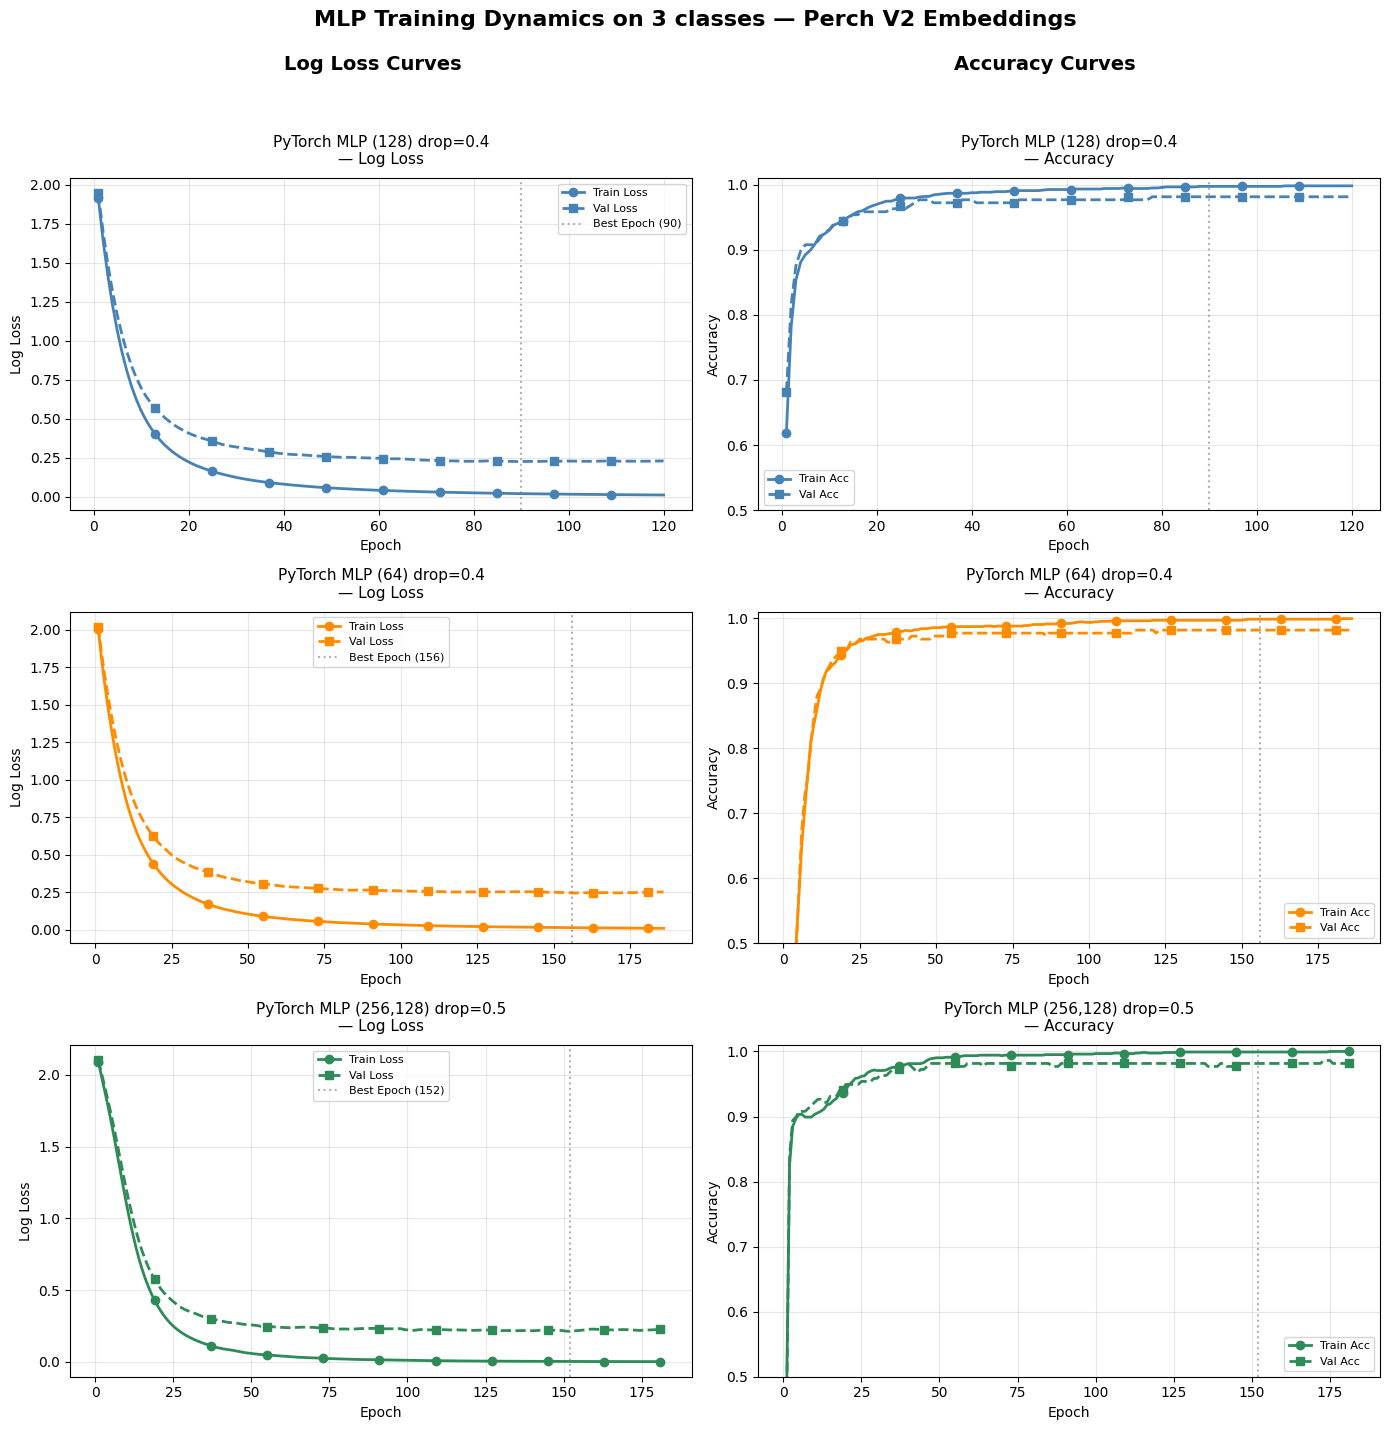

In [18]:
import matplotlib.pyplot as plt
import numpy as np


color_palette = ['steelblue', 'darkorange', 'seagreen']
colors = {name: color_palette[i % len(color_palette)] for i, name in enumerate(mlp_results)}

n_models = len(mlp_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]  # ensure 2D indexing works

fig.suptitle('MLP Training Dynamics on 3 classes — Perch V2 Embeddings',
             fontsize=16, fontweight='bold', y=0.98)

for idx, (name, res) in enumerate(mlp_results.items()):
    color = colors[name]
    epochs = np.arange(1, res['n_iter'] + 1)

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, res['train_losses'], label='Train Loss',
                 color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_loss.plot(epochs, res['val_losses'], label='Val Loss',
                 color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_loss.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6,
                    label=f'Best Epoch ({res["best_epoch"]})')
    ax_loss.set_title(f'{name}\n— Log Loss', fontsize=11, pad=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Log Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, res['train_accs'], label='Train Acc',
                color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_acc.plot(epochs, res['val_accs'], label='Val Acc',
                color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_acc.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6)
    ax_acc.set_title(f'{name}\n— Accuracy', fontsize=11, pad=10)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8)
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0.5, 1.01)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
fig.text(0.27, 0.94, 'Log Loss Curves', fontsize=14, fontweight='bold', ha='center')
fig.text(0.75, 0.94, 'Accuracy Curves', fontsize=14, fontweight='bold', ha='center')

plt.savefig(f'{save_dir}/figures/mlp_4chart_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

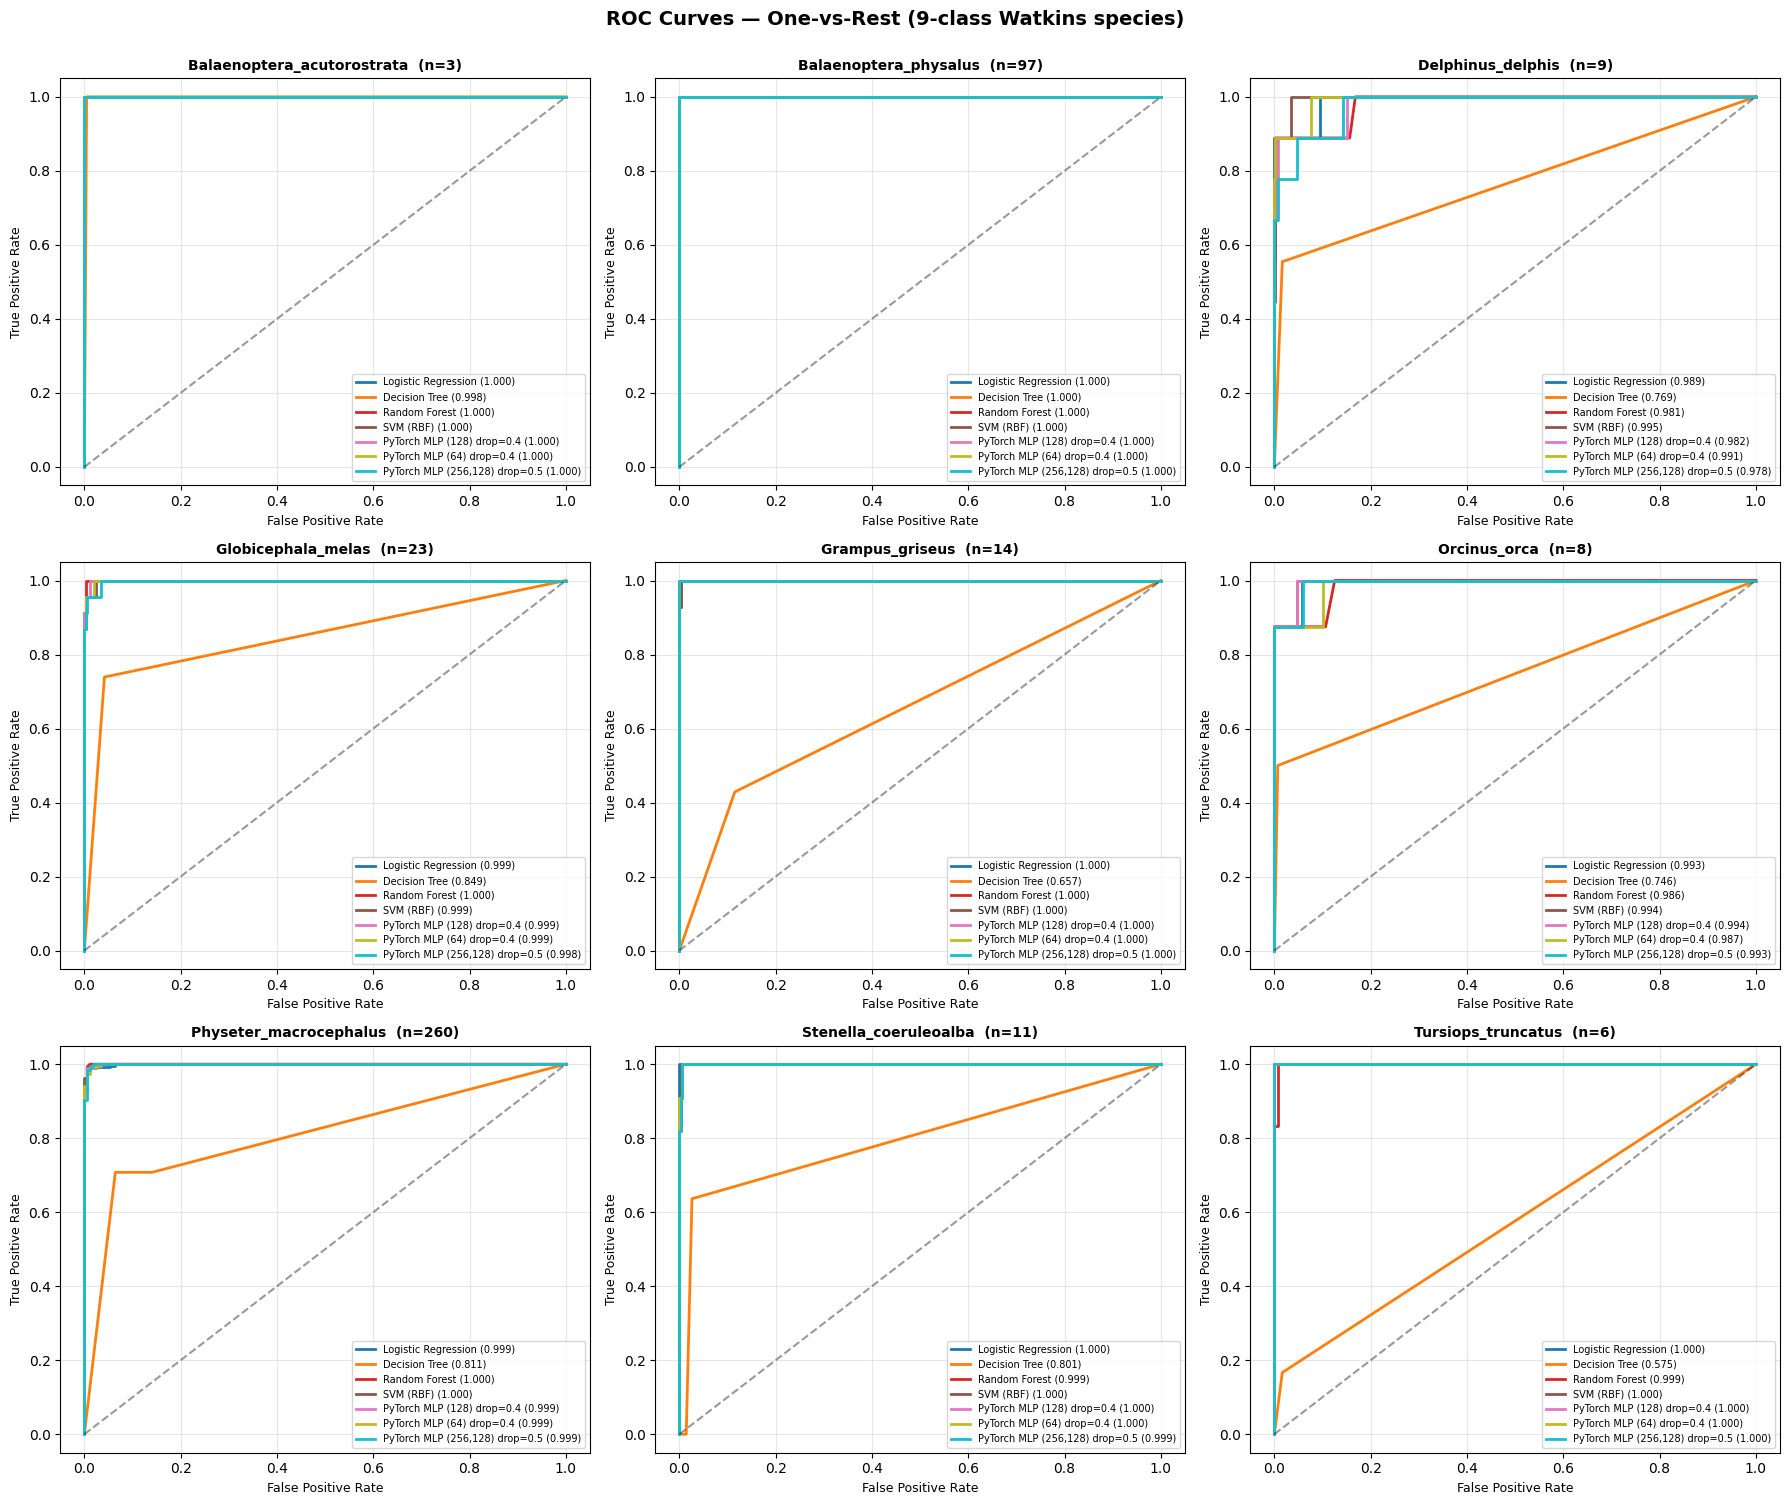

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

# All classifiers (sklearn + MLP) trained on the 9-class Watkins task
all_clf = {**results, **mlp_results}

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# 9 subplots in a 3x3 grid is much more readable than 1x9
n_cols = 3
n_rows = int(np.ceil(n_classes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

colors_roc = plt.cm.tab10(np.linspace(0, 1, len(all_clf)))

for class_idx, cn in enumerate(class_names):
    ax = axes[class_idx]
    for model_idx, (name, res) in enumerate(all_clf.items()):
        proba = res['y_proba']
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], proba[:, class_idx])
        try:
            auc = roc_auc_score(y_test_bin[:, class_idx], proba[:, class_idx])
            label = f'{name} ({auc:.3f})'
        except ValueError:
            # Class might have 0 positives in test set
            auc = float('nan')
            label = f'{name} (n/a)'
        ax.plot(fpr, tpr, label=label, color=colors_roc[model_idx], linewidth=2)

    n_pos = int(y_test_bin[:, class_idx].sum())
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_title(f'{cn}  (n={n_pos})', fontsize=10, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(alpha=0.3)

# Hide unused subplots
for j in range(n_classes, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROC Curves — One-vs-Rest (9-class Watkins species)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/roc_curves_9class.png',
            dpi=150, bbox_inches='tight')
plt.show()

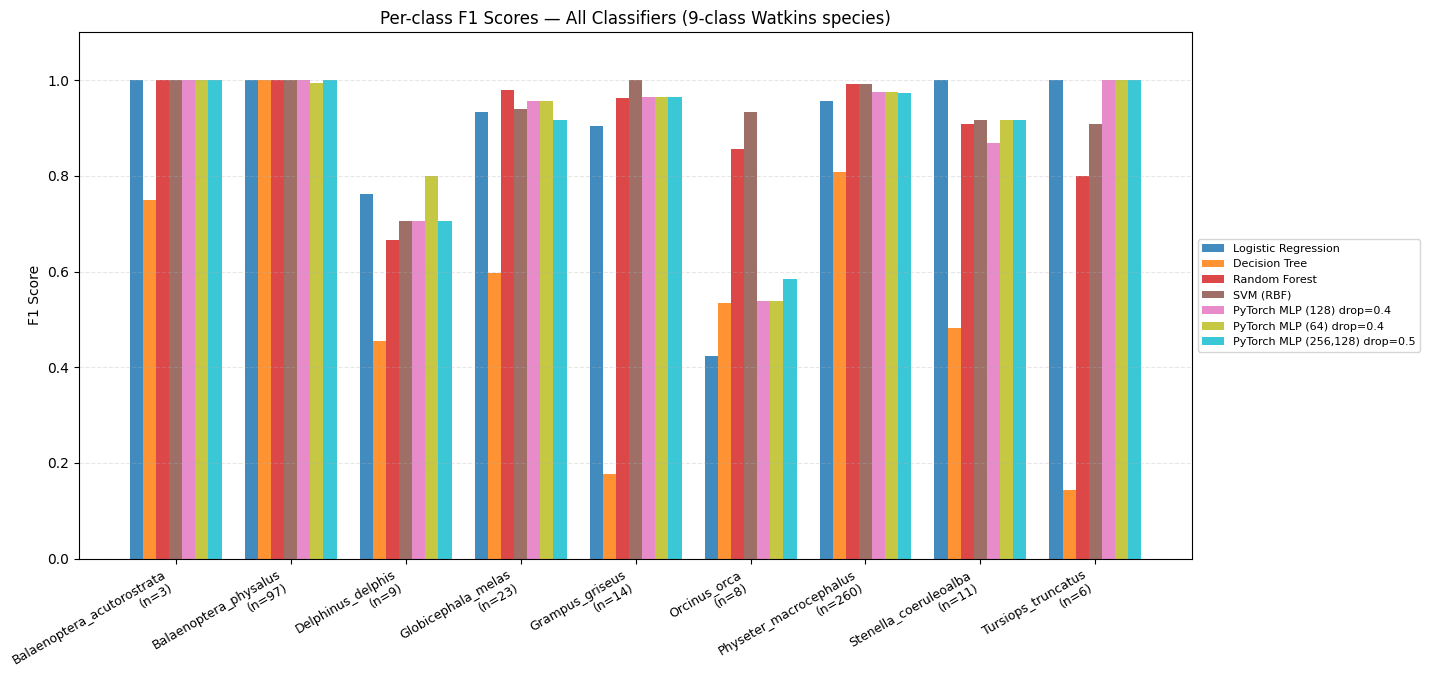

In [20]:
#@title Per-class F1 comparison bar chart — 9-class Watkins species

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

all_clf = {**results, **mlp_results}

n_clf = len(all_clf)
n_cls = len(class_names)

# tab10 only has 10 distinct colors — switch to tab20 if we exceed that
cmap = plt.cm.tab10 if n_clf <= 10 else plt.cm.tab20
colors = cmap(np.linspace(0, 1, min(n_clf, cmap.N)))

x = np.arange(n_cls)
width = 0.8 / n_clf

fig, ax = plt.subplots(figsize=(max(12, n_cls * 1.6), 7))

for i, (name, res) in enumerate(all_clf.items()):
    y_pred_i = res['y_pred'] if 'y_pred' in res else res['y_proba'].argmax(axis=1)
    f1_per = f1_score(y_test, y_pred_i,
                      labels=list(range(n_cls)), average=None, zero_division=0)
    offset = (i - n_clf / 2 + 0.5) * width
    ax.bar(x + offset, f1_per, width, label=name,
           color=colors[i % len(colors)], alpha=0.85)

# Annotate each x-tick with test-set support so sparse classes are visually obvious
test_support = np.bincount(y_test, minlength=n_cls)
xtick_labels = [f'{cn}\n(n={s})' for cn, s in zip(class_names, test_support)]

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class F1 Scores — All Classifiers (9-class Watkins species)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/f1_comparison_all_classifiers_watkins.png',
            dpi=150, bbox_inches='tight')
plt.show()

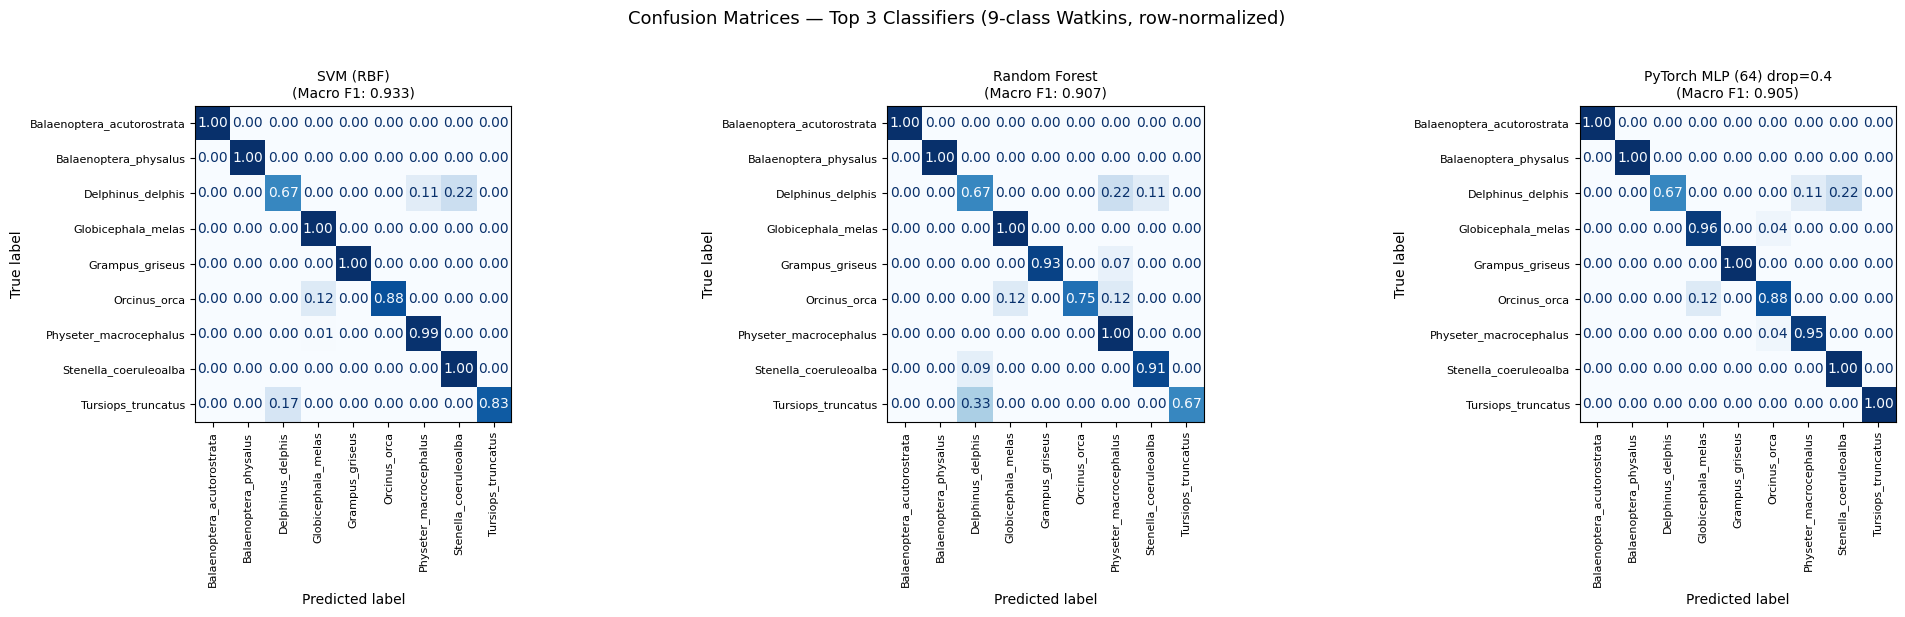

In [21]:
#@title Confusion matrices — Top N classifiers by Macro F1 (9-class Watkins)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

TOP_N = 3

all_clf = {**results, **mlp_results}
top_clf = sorted(all_clf.items(), key=lambda x: x[1]['f1_macro'], reverse=True)[:TOP_N]

fig, axes = plt.subplots(1, TOP_N, figsize=(7 * TOP_N, 6))
if TOP_N == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, top_clf):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        display_labels=class_names,
        ax=ax, colorbar=False, xticks_rotation='vertical', cmap='Blues',
        normalize='true',  # row-normalized: shows recall per class
        values_format='.2f',
    )
    ax.set_title(f'{name}\n(Macro F1: {res["f1_macro"]:.3f})', fontsize=10)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Confusion Matrices — Top {TOP_N} Classifiers (9-class Watkins, row-normalized)',
             fontsize=13, y=1.02)
plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/confusion_matrices_top{TOP_N}_watkins.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [22]:
#@title Save full results to CSV — ALL classifiers (9-class Watkins)
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import pandas as pd

all_clf = {**results, **mlp_results}

rows = []
for name, res in all_clf.items():
    auc = None
    if 'y_proba' in res and res['y_proba'].ndim == 2:
        try:
            auc = roc_auc_score(y_test, res['y_proba'], multi_class='ovr', average='weighted')
        except ValueError:
            auc = None

    p, r, f, s = precision_recall_fscore_support(
        y_test, res['y_pred'], labels=range(len(class_names)), zero_division=0
    )
    row = {
        'classifier': name,
        'macro_f1': res['f1_macro'],
        'roc_auc_ovr': auc,
        'time_seconds': res.get('time_s', None),
    }
    for i, cls in enumerate(class_names):
        row[f'{cls}_precision'] = round(p[i], 3)
        row[f'{cls}_recall']    = round(r[i], 3)
        row[f'{cls}_f1']        = round(f[i], 3)
        row[f'{cls}_support']   = s[i]
    rows.append(row)

results_df = pd.DataFrame(rows)
priority_cols = ['classifier', 'macro_f1', 'roc_auc_ovr', 'time_seconds']
cols = priority_cols + [c for c in results_df.columns if c not in priority_cols]
results_df = results_df[cols].sort_values('macro_f1', ascending=False).reset_index(drop=True)

os.makedirs(save_dir, exist_ok=True)
csv_path = f'{save_dir}/perch_v2_all_classifiers_results_watkins.csv'
results_df.to_csv(csv_path, index=False)
print(f'Saved {len(results_df)} classifiers to {csv_path}')
display(results_df.round(3))

Saved 7 classifiers to /data2/mromaniuc/cet-det/models/perch_v2/WATKINS/perch_v2_all_classifiers_results_watkins.csv


,classifier,macro_f1,roc_auc_ovr,time_seconds,Balaenoptera_acutorostrata_precision,Balaenoptera_acutorostrata_recall,Balaenoptera_acutorostrata_f1,Balaenoptera_acutorostrata_support,Balaenoptera_physalus_precision,Balaenoptera_physalus_recall,...,Physeter_macrocephalus_f1,Physeter_macrocephalus_support,Stenella_coeruleoalba_precision,Stenella_coeruleoalba_recall,Stenella_coeruleoalba_f1,Stenella_coeruleoalba_support,Tursiops_truncatus_precision,Tursiops_truncatus_recall,Tursiops_truncatus_f1,Tursiops_truncatus_support
0,SVM (RBF),0.933,1.000,4.895,1.0,1.0,1.00,3,1.00,1.0,...,0.992,260,0.846,1.000,0.917,11,1.000,0.833,0.909,6
1,Random Forest,0.907,0.999,1.004,1.0,1.0,1.00,3,1.00,1.0,...,0.992,260,0.909,0.909,0.909,11,1.000,0.667,0.800,6
2,PyTorch MLP (64) drop=0.4,0.905,0.999,2.401,1.0,1.0,1.00,3,0.99,1.0,...,0.974,260,0.846,1.000,0.917,11,1.000,1.000,1.000,6
3,"PyTorch MLP (256,128) drop=0.5",0.896,0.999,2.869,1.0,1.0,1.00,3,1.00,1.0,...,0.972,260,0.846,1.000,0.917,11,1.000,1.000,1.000,6
4,PyTorch MLP (128) drop=0.4,0.890,0.999,2.339,1.0,1.0,1.00,3,1.00,1.0,...,0.974,260,0.833,0.909,0.870,11,1.000,1.000,1.000,6
5,Logistic Regression,0.887,0.999,4.210,1.0,1.0,1.00,3,1.00,1.0,...,0.956,260,1.000,1.000,1.000,11,1.000,1.000,1.000,6
6,Decision Tree,0.549,0.846,1.460,0.6,1.0,0.75,3,1.00,1.0,...,0.809,260,0.389,0.636,0.483,11,0.125,0.167,0.143,6


# 5-classs dimensionality reduction

Running full PCA...

Total components: 1536

PCA Variance Explained (first 30 components):
Component  Variance Explained (%)  Cumulative (%)
      PC1                 16.5448         16.5448
      PC2                  8.4078         24.9526
      PC3                  4.9135         29.8661
      PC4                  3.9534         33.8195
      PC5                  3.0846         36.9041
      PC6                  2.6143         39.5185
      PC7                  2.1534         41.6719
      PC8                  1.8737         43.5456
      PC9                  1.8269         45.3724
     PC10                  1.5549         46.9273
     PC11                  1.3455         48.2729
     PC12                  1.1516         49.4244
     PC13                  1.1356         50.5600
     PC14                  1.0841         51.6442
     PC15                  0.9639         52.6081
     PC16                  0.9264         53.5345
     PC17                  0.8901         54.4246
     PC18

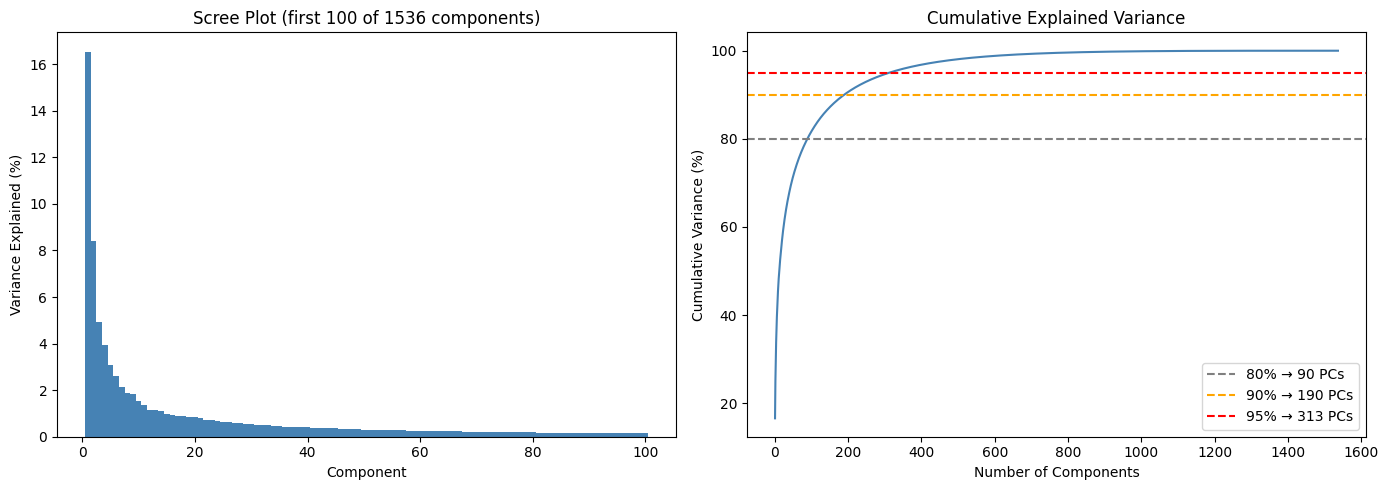

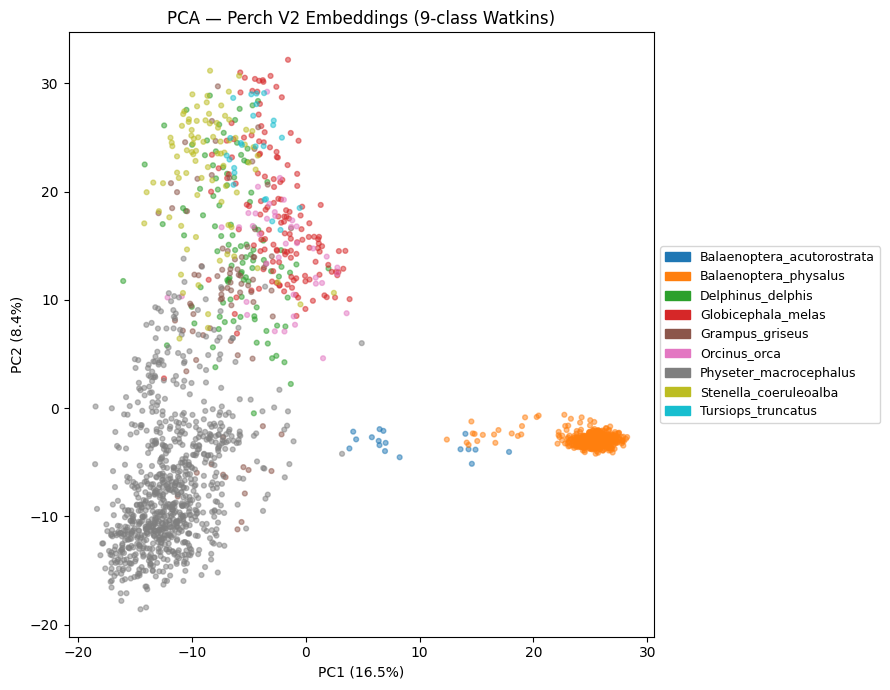


PCA-reduced shape for t-SNE/UMAP input: (1877, 190)

Running t-SNE with multiple distance metrics...
  t-SNE metric: euclidean...
  t-SNE metric: cosine...
  t-SNE metric: manhattan...
  t-SNE metric: correlation...


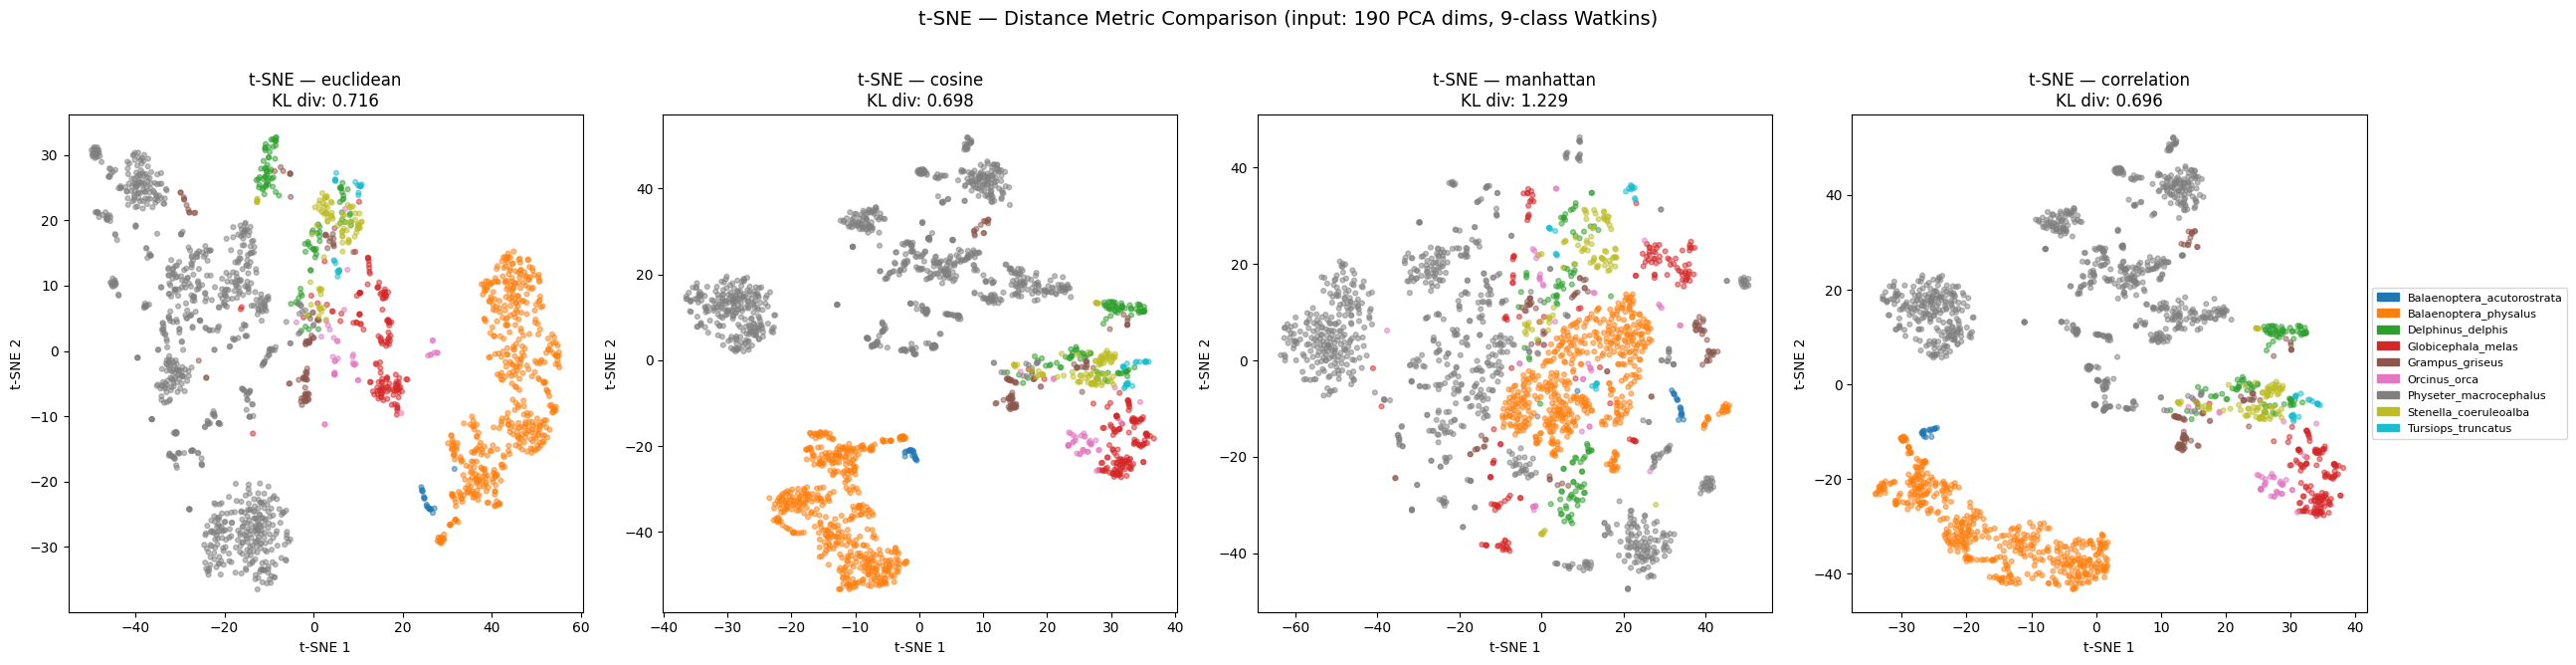


Running UMAP with multiple distance metrics...
  UMAP metric: euclidean...
  UMAP metric: cosine...
  UMAP metric: manhattan...
  UMAP metric: correlation...


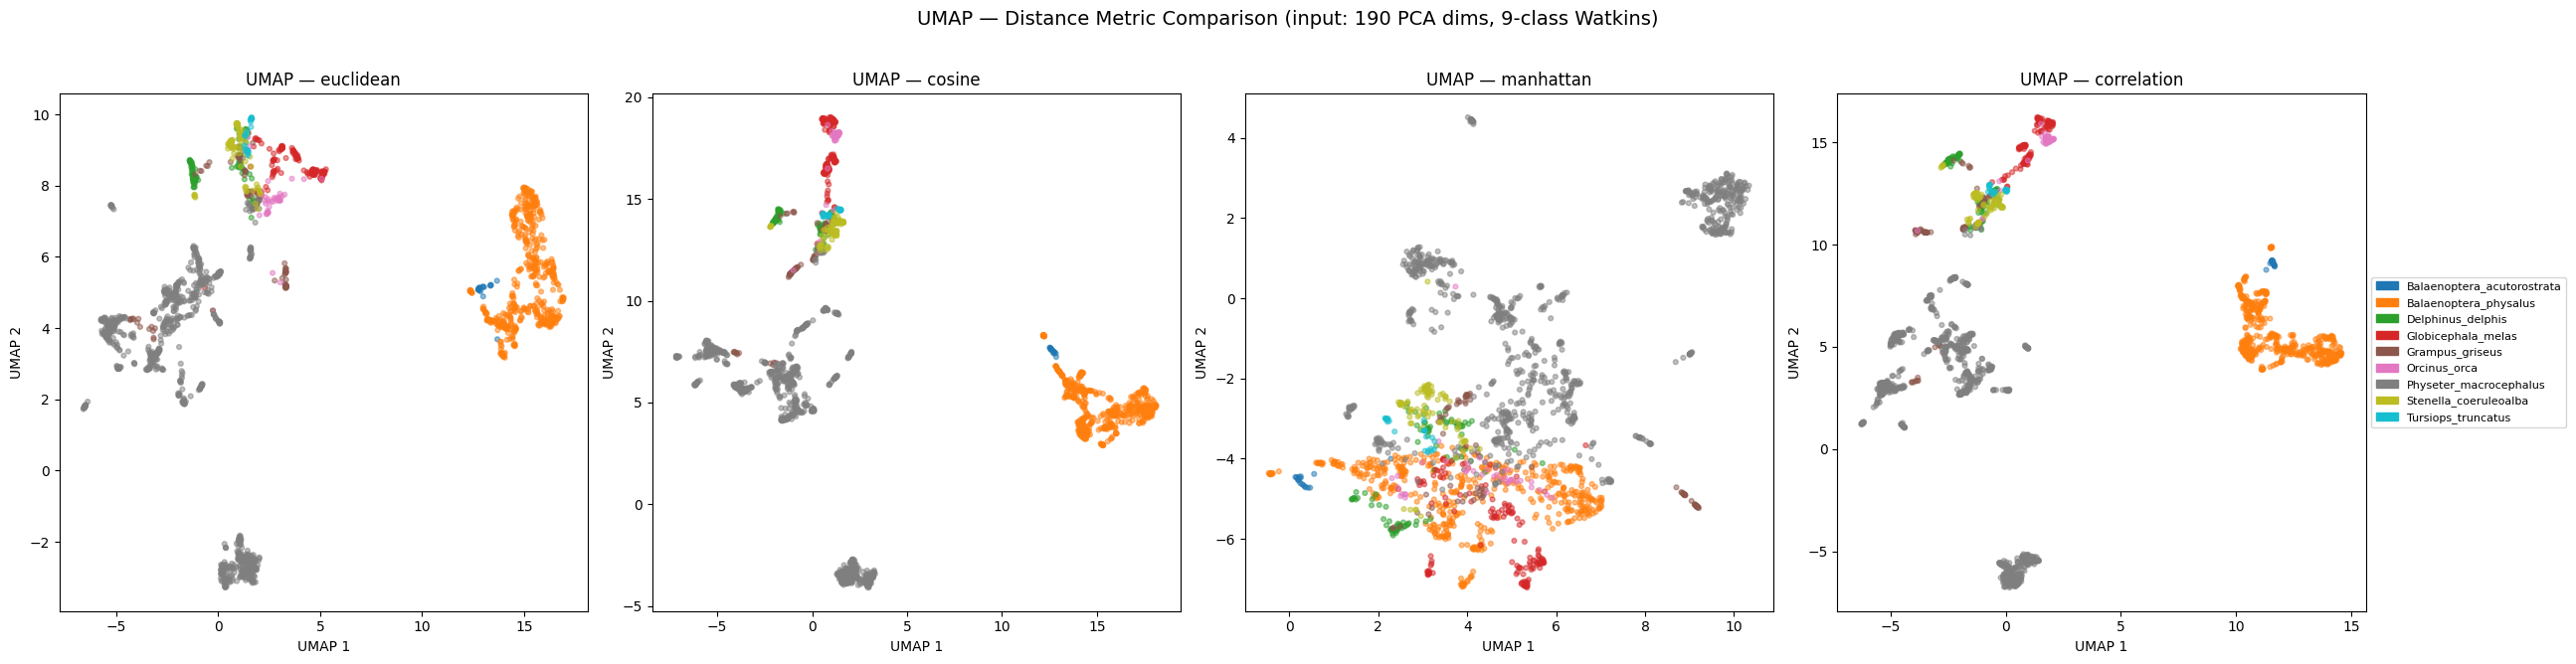


SUMMARY
PCA input dims: 1536 → reduced to 190 (90% variance)

t-SNE KL Divergence by metric (lower = better fit):
  correlation      KL: 0.6956
  cosine           KL: 0.6980
  euclidean        KL: 0.7165
  manhattan        KL: 1.2286

All coordinates saved.


In [23]:
#@title Dimensionality reduction — PCA + t-SNE & UMAP (9-class Watkins)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Standardize embeddings
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_clean)

# Color setup — 9 species, distinct colors from tab10
species_list = sorted(np.unique(y_clean))
tab_colors = plt.cm.tab10(np.linspace(0, 1, len(species_list)))
colors_map = {sp: tab_colors[i] for i, sp in enumerate(species_list)}
c = np.array([colors_map[label] for label in y_clean])
alpha = 0.5
s = 12
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]

os.makedirs(f'{save_dir}/dim_red', exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. FULL PCA — Variance analysis
# ═══════════════════════════════════════════════════════════════════════════════
print('Running full PCA...')
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

n_total = len(pca_full.explained_variance_ratio_)
cumvar_full = np.cumsum(pca_full.explained_variance_ratio_) * 100

var_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(n_total)],
    'Variance Explained (%)': pca_full.explained_variance_ratio_ * 100,
    'Cumulative (%)': cumvar_full
})

print(f'\nTotal components: {n_total}')
print(f'\nPCA Variance Explained (first 30 components):')
print(var_df.head(30).to_string(index=False, float_format='%.4f'))

n80 = int(np.argmax(cumvar_full >= 80) + 1)
n90 = int(np.argmax(cumvar_full >= 90) + 1)
n95 = int(np.argmax(cumvar_full >= 95) + 1)
n99 = int(np.argmax(cumvar_full >= 99) + 1)
print(f'\nComponents for 80% variance: {n80}')
print(f'Components for 90% variance: {n90}')
print(f'Components for 95% variance: {n95}')
print(f'Components for 99% variance: {n99}')

n_pca = n90
print(f'\n→ Using {n_pca} PCA components for t-SNE/UMAP input (90% variance)')

# Scree + cumulative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
n_show = min(100, n_total)
ax1.bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
        color='steelblue', width=1.0)
ax1.set_xlabel('Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title(f'Scree Plot (first {n_show} of {n_total} components)')

ax2.plot(range(1, n_total + 1), cumvar_full, color='steelblue')
ax2.axhline(80, color='gray',   linestyle='--', label=f'80% → {n80} PCs')
ax2.axhline(90, color='orange', linestyle='--', label=f'90% → {n90} PCs')
ax2.axhline(95, color='red',    linestyle='--', label=f'95% → {n95} PCs')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_full_variance_watkins.png', dpi=150)
plt.show()

# PCA 2D scatter
pca2 = PCA(n_components=2, random_state=random_seed)
X_pca2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=c, alpha=alpha, s=s)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Perch V2 Embeddings (9-class Watkins)')
ax.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_2d_watkins.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. PCA-reduce for t-SNE and UMAP input
# ═══════════════════════════════════════════════════════════════════════════════
pca_red = PCA(n_components=n_pca, random_state=random_seed)
X_pca_red = pca_red.fit_transform(X_scaled)
print(f'\nPCA-reduced shape for t-SNE/UMAP input: {X_pca_red.shape}')

# ═══════════════════════════════════════════════════════════════════════════════
# 3. t-SNE — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

print('\nRunning t-SNE with multiple distance metrics...')
fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))
tsne_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  t-SNE metric: {metric}...')
    tsne = TSNE(
        n_components=2,
        perplexity=40,
        learning_rate='auto',
        init='random' if metric != 'euclidean' else 'pca',
        max_iter=1000,
        metric=metric,
        random_state=random_seed,
        verbose=0
    )
    X_tsne = tsne.fit_transform(X_pca_red)
    tsne_results[metric] = {'coords': X_tsne, 'kl': tsne.kl_divergence_}

    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f't-SNE — {metric}\nKL div: {tsne.kl_divergence_:.3f}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

axes[-1].legend(handles=legend_patches, loc='center left',
                bbox_to_anchor=(1, 0.5), fontsize=8)

plt.suptitle(f't-SNE — Distance Metric Comparison '
             f'(input: {n_pca} PCA dims, 9-class Watkins)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_metrics_comparison_watkins.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. UMAP — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
print('\nRunning UMAP with multiple distance metrics...')
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap

fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))
umap_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  UMAP metric: {metric}...')
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.1,
        n_components=2,
        metric=metric,
        random_state=random_seed,
        verbose=False
    )
    X_umap = reducer.fit_transform(X_pca_red)
    umap_results[metric] = X_umap

    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f'UMAP — {metric}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

axes[-1].legend(handles=legend_patches, loc='center left',
                bbox_to_anchor=(1, 0.5), fontsize=8)

plt.suptitle(f'UMAP — Distance Metric Comparison '
             f'(input: {n_pca} PCA dims, 9-class Watkins)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/umap_metrics_comparison_watkins.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Summary + save coords
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'PCA input dims: {X_scaled.shape[1]} → reduced to {n_pca} (90% variance)')
print(f'\nt-SNE KL Divergence by metric (lower = better fit):')
for metric, data in sorted(tsne_results.items(), key=lambda x: x[1]['kl']):
    print(f'  {metric:15s}  KL: {data["kl"]:.4f}')

np.save(f'{save_dir}/dim_red/coords_pca2_watkins.npy', X_pca2)
for metric in metrics:
    np.save(f'{save_dir}/dim_red/coords_tsne_{metric}_watkins.npy',
            tsne_results[metric]['coords'])
    np.save(f'{save_dir}/dim_red/coords_umap_{metric}_watkins.npy',
            umap_results[metric])
print('\nAll coordinates saved.')

The PCA visualization demonstrates that Perch V2 has learned biologically
meaningful features rather than merely recording-level artifacts. Along PC1
alone, the model cleanly separates baleen whales (Balaenoptera acutorostrata,
B. physalus) from toothed whales — the deepest split in
Cetacea. Within the baleen group, the two Balaenoptera species are themselves
clearly resolved into distinct clusters.

Within the toothed whale cloud, Physeter macrocephalus (sperm whale) occupies
a distinct region in the lower portion — consistent with its status as the
sole Physeteridae representative and its uniquely slow, broadband click
pattern, acoustically dissimilar from the Delphinidae. The five Delphinidae
species (Delphinus, Stenella, Tursiops, Globicephala, Orcinus) overlap
substantially in the upper cluster, suggesting that 2D PCA is insufficient
to resolve them but that they share common spectral characteristics.
Grampus griseus appears as a partial bridge between the dolphin cloud and
Physeter, which is consistent with its known acoustic preference for
clicks over tonal whistles relative to other delphinids.

Given that PC1 and PC2 together capture only 24.9% of the variance, the
clarity of the baleen/toothed separation and the within-baleen species
resolution indicate that Perch's embeddings encode these distinctions as
dominant features, not merely subtle ones. This is strong evidence against
the shortcut-learning hypothesis, since recording-fingerprint artifacts
would not align with taxonomic structure across decades of recordings made
with different equipment by different recordists.

In [ ]:
#@title Quantitative quality metrics

from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness

print('\n' + '=' * 80)
print('QUANTITATIVE QUALITY METRIC')
print('=' * 80)
print(f'{"Method":<20} {"Metric":<15} {"Trustworthiness":>16} {"Silhouette":>12}')
print('-' * 80)

# Use actual 5-class labels (encoded as ints for silhouette)
le_viz = LabelEncoder()
y_viz = le_viz.fit_transform(y_clean)

# t-SNE quality
for metric, data in tsne_results.items():
    trust = trustworthiness(X_pca_red, data['coords'], n_neighbors=15)
    sil = silhouette_score(data['coords'], y_viz)
    print(f'{"t-SNE":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# UMAP quality
for metric, coords in umap_results.items():
    trust = trustworthiness(X_pca_red, coords, n_neighbors=15)
    sil = silhouette_score(coords, y_viz)
    print(f'{"UMAP":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# PCA baseline
trust_pca = trustworthiness(X_pca_red, X_pca2, n_neighbors=15)
sil_pca = silhouette_score(X_pca2, y_viz)
print(f'{"PCA (2D)":<20} {"euclidean":<15} {trust_pca:>16.4f} {sil_pca:>12.4f}')


QUANTITATIVE QUALITY METRIC
Method               Metric           Trustworthiness   Silhouette
--------------------------------------------------------------------------------
t-SNE                euclidean                 0.9758       0.1047
t-SNE                cosine                    0.9777       0.1659
t-SNE                manhattan                 0.9345      -0.0570
t-SNE                correlation               0.9779       0.1305

UMAP                 euclidean                 0.9704       0.1153
UMAP                 cosine                    0.9716       0.1822
UMAP                 manhattan                 0.9189      -0.1283
UMAP                 correlation               0.9713       0.2007

PCA (2D)             euclidean                 0.7808       0.4458


: 